In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyleoclim.utils.wavelet import cwt_coherence
import scipy.signal as ss
from scipy.interpolate import PchipInterpolator, interp1d
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from pipeline import *

In [2]:
# Load data
df = pd.read_excel("data/nc0304_pilot_data_truncated.xlsx")

In [3]:
####INTERPOLATE data####
time_col = "time"
angle_cols = ["p1_unwrapped", "p2_unwrapped"]
current_cols = ["i1", "i2"]

# 1) sort + collapse duplicate timestamps
df = df.sort_values(time_col)
df = df.groupby(time_col, as_index=False).mean()

# extract columns
cosxpi = df["time"].to_numpy() 
p1_angle = df["angle_p1"].to_numpy()
p2_angle = df["angle_p2"].to_numpy()
i1 = df["i1"].to_numpy()
i2 = df["i2"].to_numpy()
p1 = df["p1"].to_numpy()
p2 = df["p2"].to_numpy()

# 2) unwrap
p1_unwrapped = np.unwrap(p1_angle-np.pi)#+np.pi 
p2_unwrapped = np.unwrap(p2_angle-np.pi)#+np.pi

#add unwrapped columns to df
df["p1_unwrapped"] = p1_unwrapped
df["p2_unwrapped"] = p2_unwrapped

# 3) make uniform 0.001s grid
dt_target = 0.001
t_new = np.arange(cosxpi.min(), cosxpi.max() + dt_target/2, dt_target)

# 4) interpolate angles (PCHIP is shape-preserving)
out = {time_col: t_new}

for c in angle_cols:
    cosx = df[c].to_numpy()
    out[c] = PchipInterpolator(cosxpi, cosx)(t_new)

# 5) interpolate currents (linear)
for c in current_cols:
    cosx = df[c].to_numpy()
    out[c] = interp1d(cosxpi, cosx, kind="linear", bounds_error=False, fill_value="extrapolate")(t_new)

df_rs = pd.DataFrame(out)

# extract resampled columns
t_rs = df_rs[time_col].to_numpy()
p1_unwrapped_rs = df_rs["p1_unwrapped"].to_numpy()
p2_unwrapped_rs = df_rs["p2_unwrapped"].to_numpy()
i1_rs = df_rs["i1"].to_numpy()
i2_rs = df_rs["i2"].to_numpy()

# 6) compute torque + velocity
df_rs["torque1"] = df_rs["i1"] * 0.011
df_rs["torque2"] = df_rs["i2"] * 0.011

df_rs["omega1"] = np.gradient(df_rs["p1_unwrapped"].to_numpy(), dt_target)
df_rs["omega2"] = np.gradient(df_rs["p2_unwrapped"].to_numpy(), dt_target)


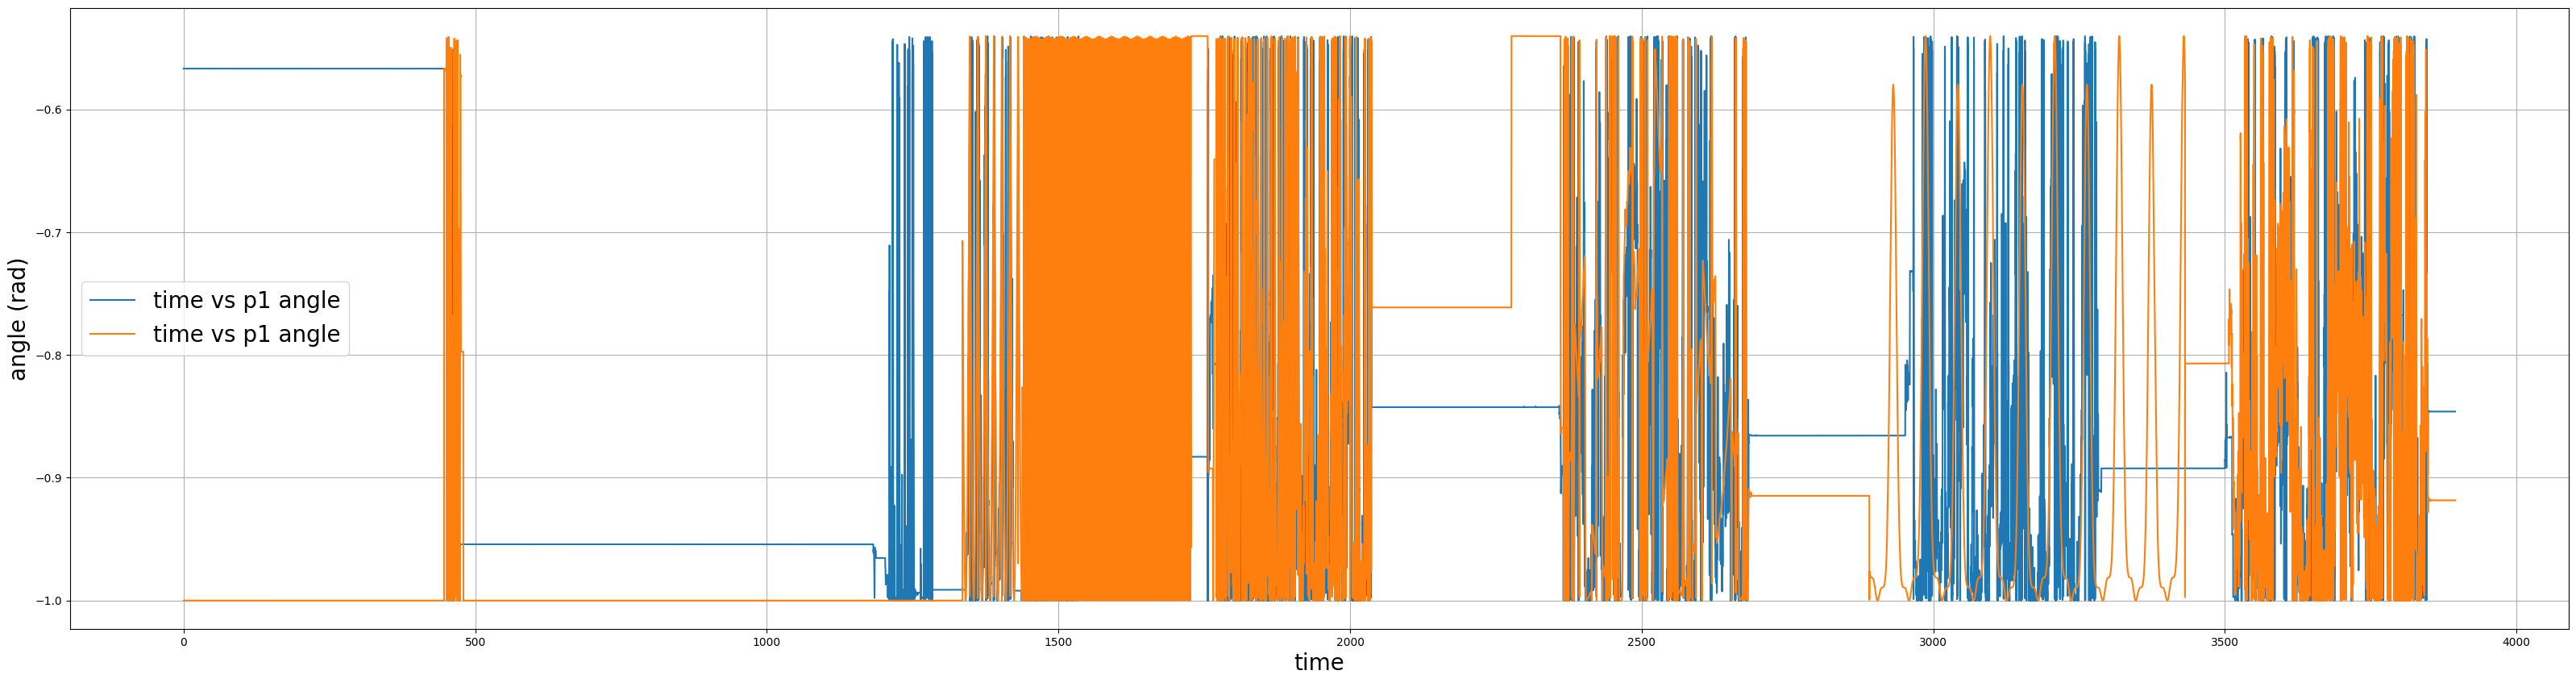

In [4]:
fig, axs = plt.subplots(1, 1, figsize=(40, 10))
axs.plot(t_rs, np.cos(p1_unwrapped_rs), label="time vs p1 angle")
axs.plot(t_rs, np.cos(p2_unwrapped_rs), label="time vs p1 angle")
plt.legend(fontsize=20)
plt.xlabel("time", fontsize=20)
plt.ylabel("angle (rad)", fontsize=20)
plt.grid(True)
# plt.xticks(np.arange(0, 4000, 100))

Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.42857143 17.5905819  57.        ]...[ 5.42857143 17.5905819  57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3


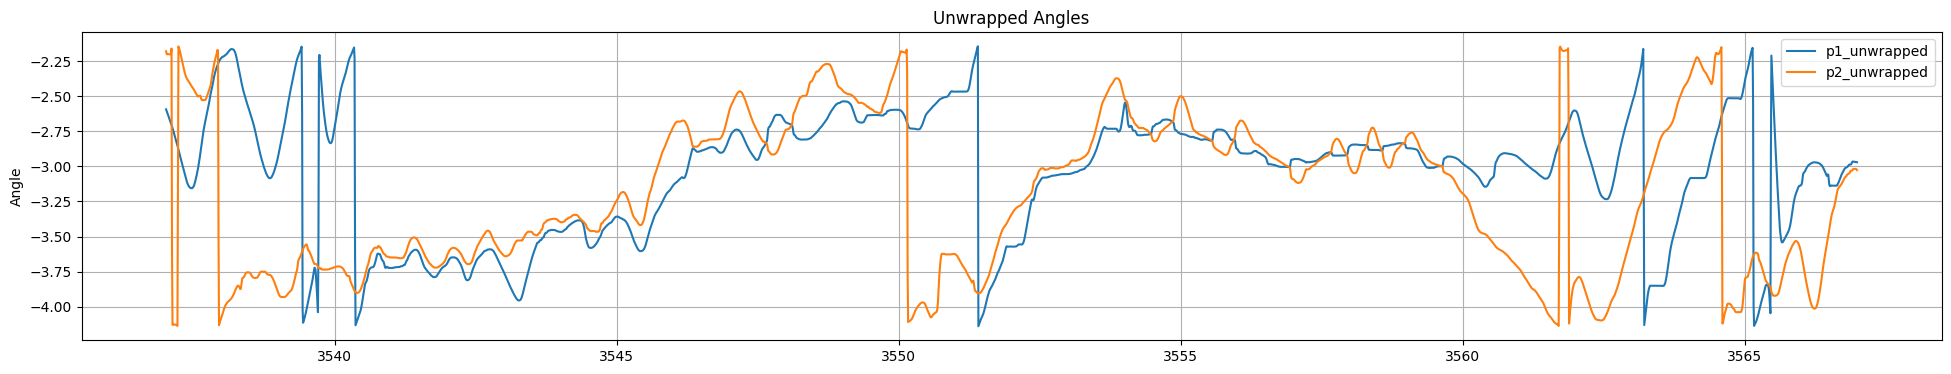

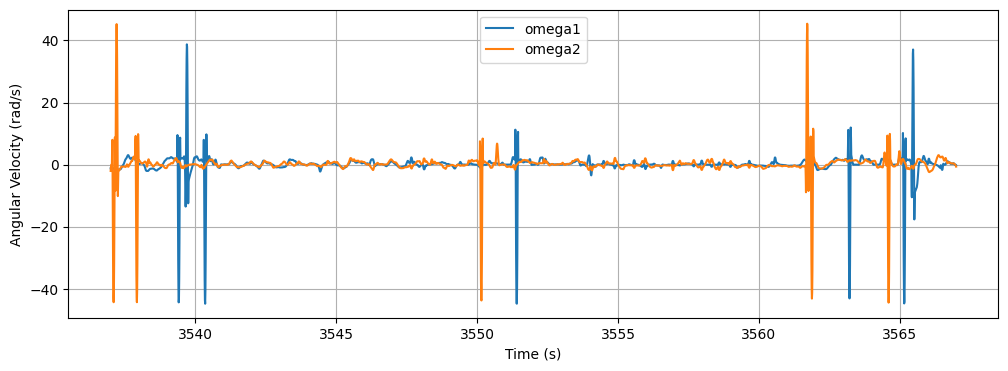

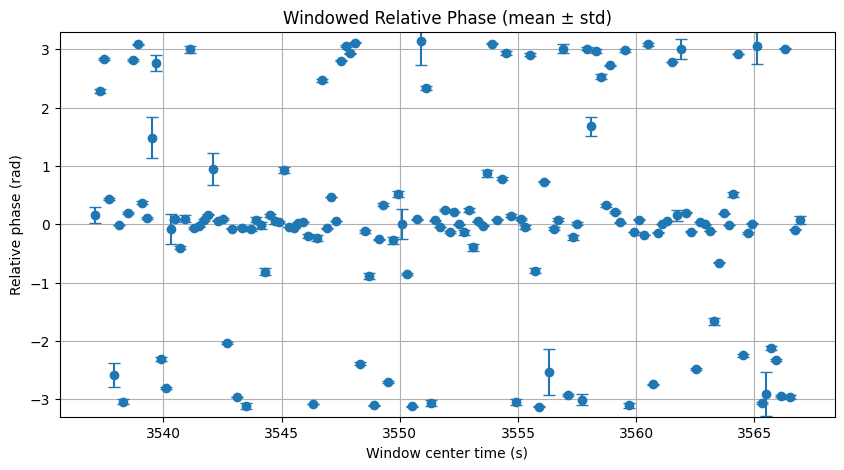

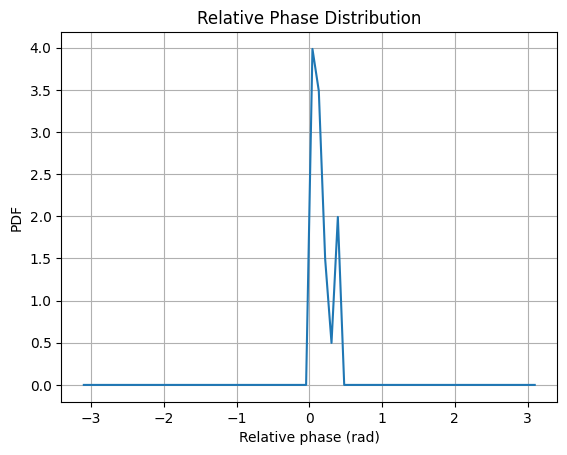

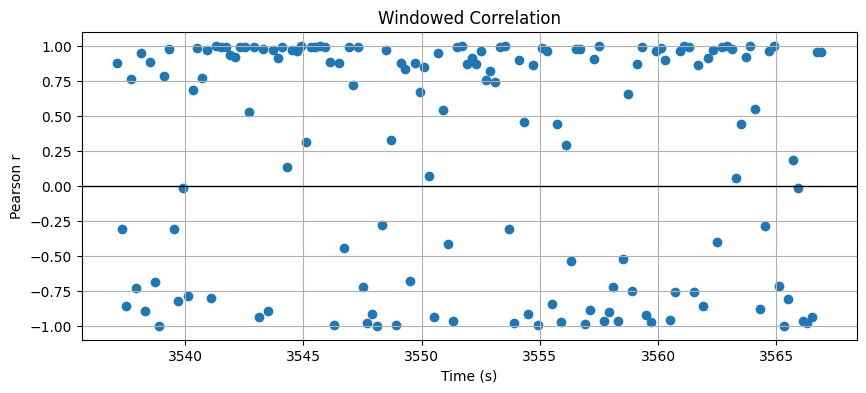

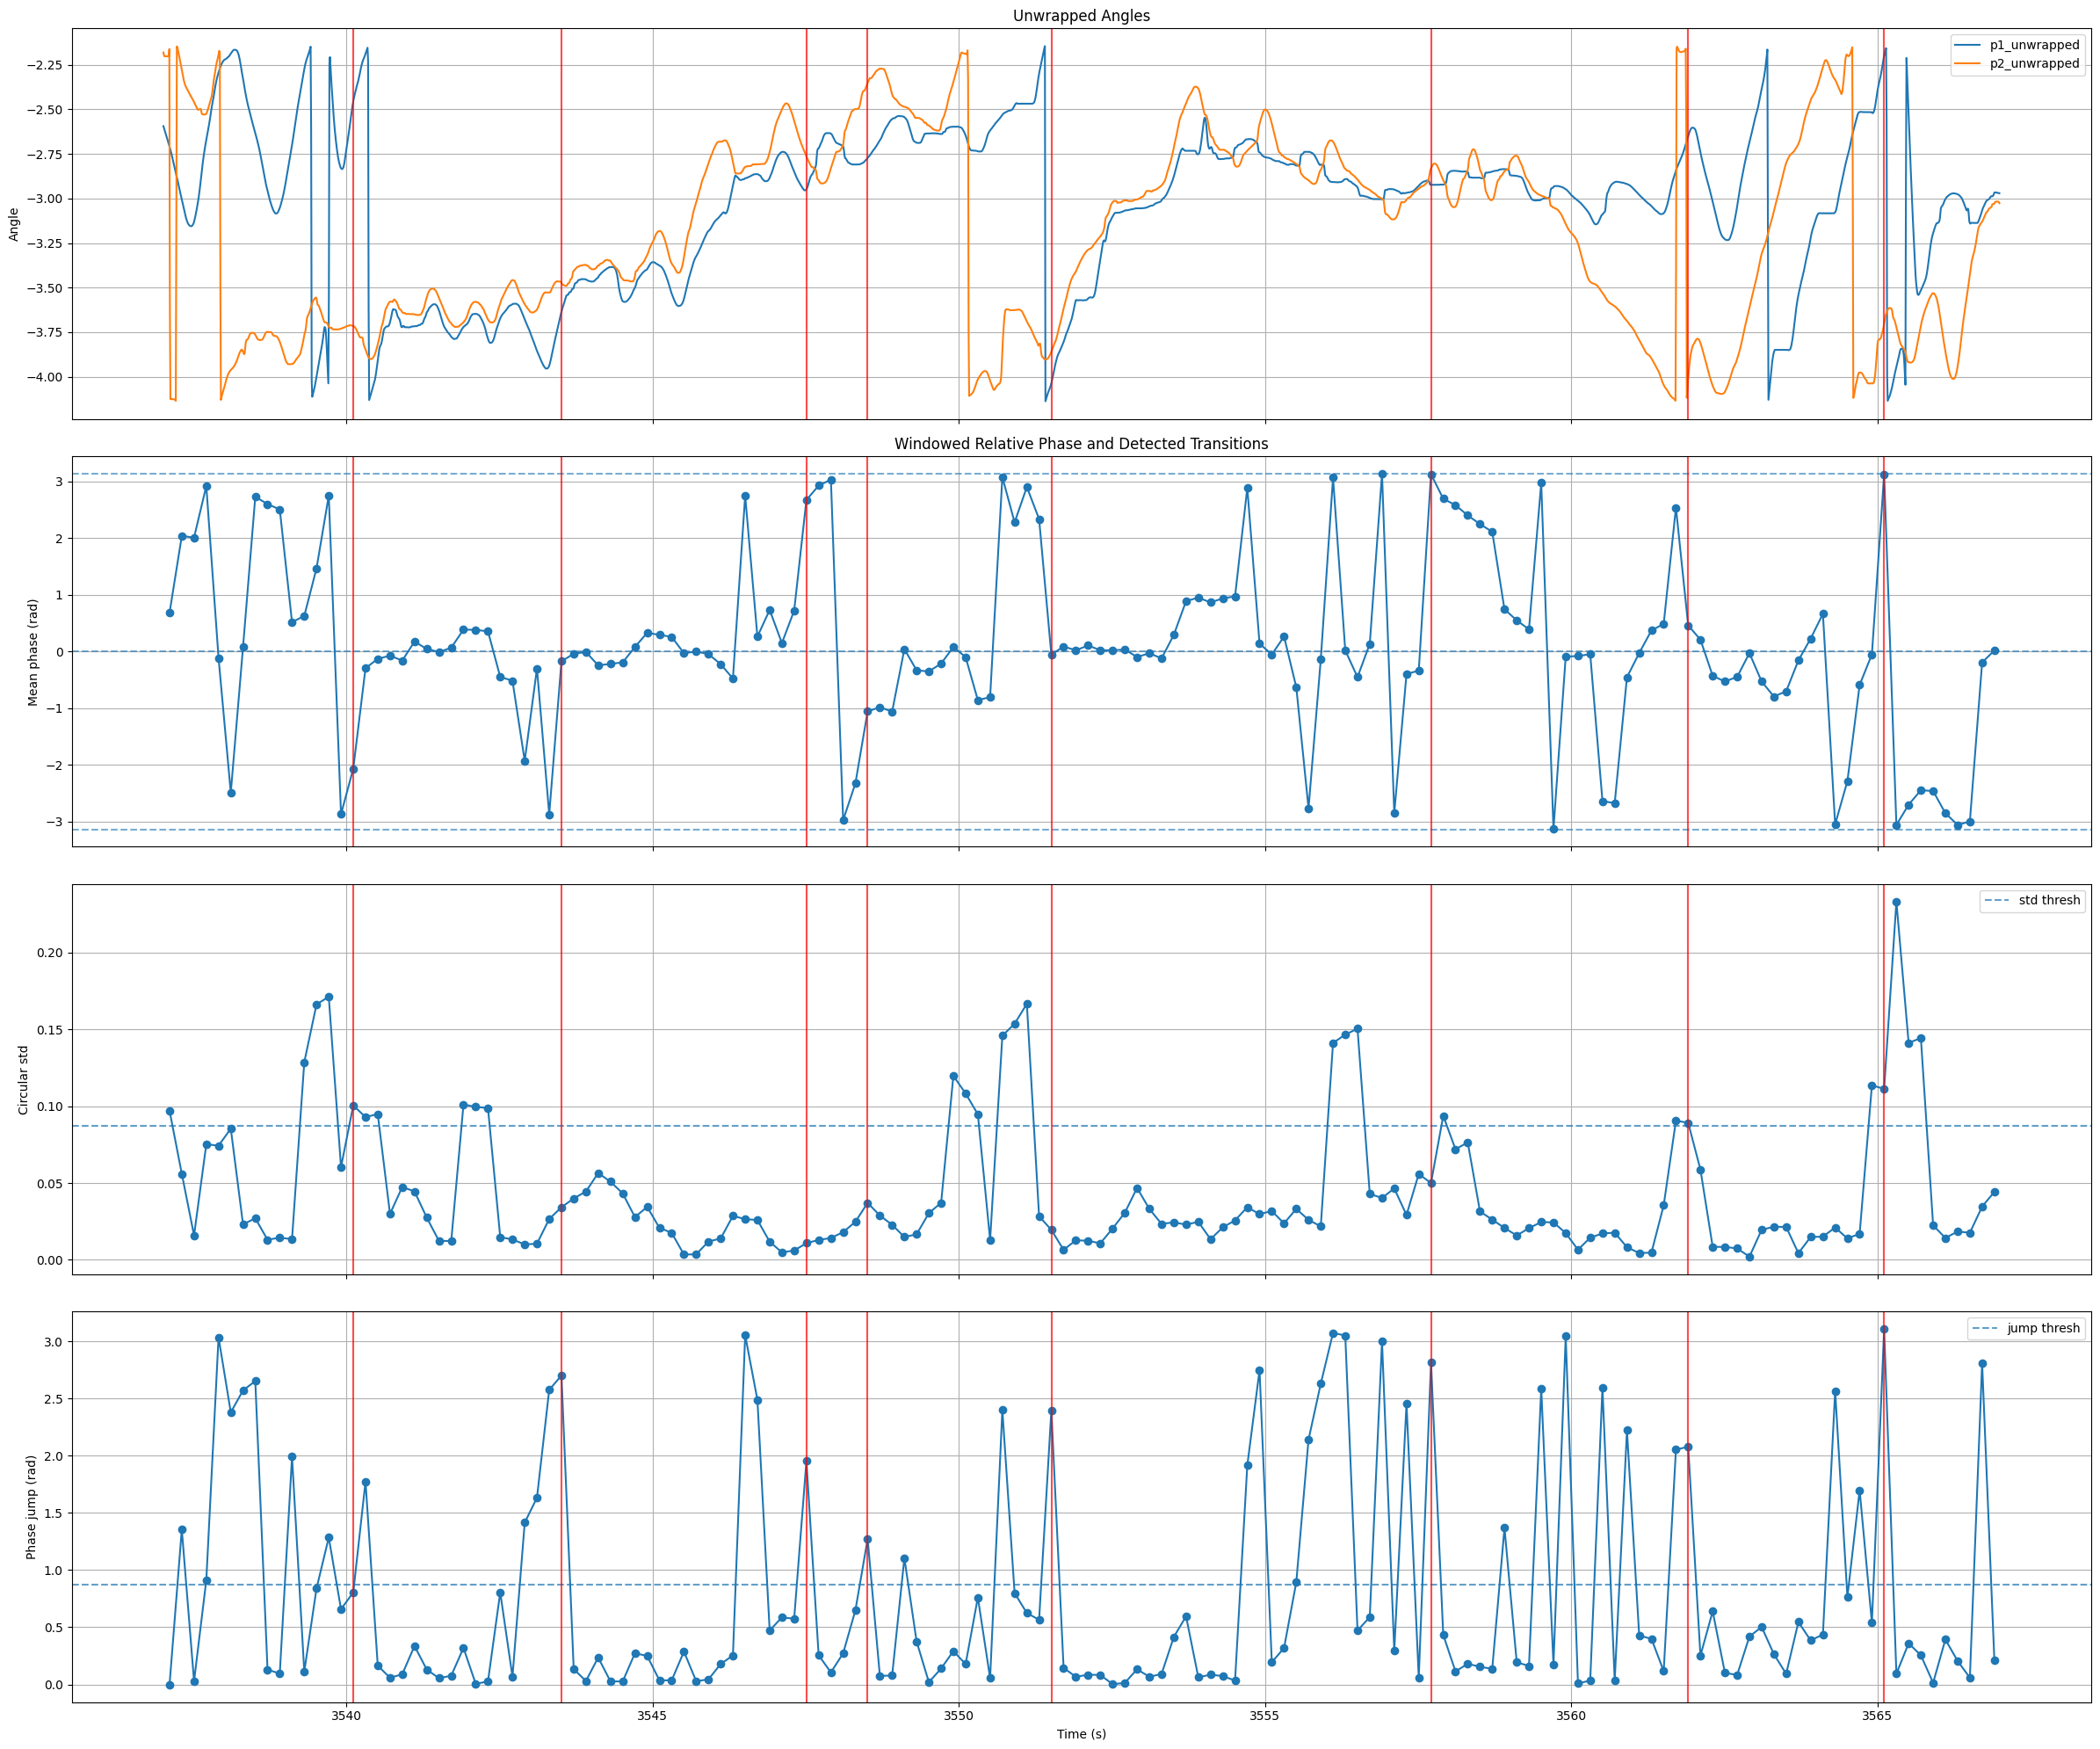

Transition at t=3540.109s | anti-phase -> intermediate | jump=46.1 deg | std=0.101
Transition at t=3543.509s | anti-phase -> in-phase | jump=154.8 deg | std=0.034
Transition at t=3547.509s | in-phase -> anti-phase | jump=111.9 deg | std=0.011
Transition at t=3548.509s | anti-phase -> intermediate | jump=72.9 deg | std=0.037
Transition at t=3551.509s | anti-phase -> in-phase | jump=137.2 deg | std=0.020
Transition at t=3557.709s | in-phase -> anti-phase | jump=161.3 deg | std=0.050
Transition at t=3561.909s | anti-phase -> in-phase | jump=119.1 deg | std=0.089
Transition at t=3565.109s | in-phase -> anti-phase | jump=177.9 deg | std=0.111


In [13]:

df_processed, phase_windows, transitions, transition_summary = run_full_pipeline(
    "data/nc0304_pilot_data_truncated.xlsx",
    3507+30,
    # 3288-30,
    3507+60,
    dt=1/114,
    window_size=0.2,
    freq_band=(0.1, 100),
    phase_jump_thresh=np.deg2rad(50),
    smooth_k=3,
    min_dwell=5,
)
"""
static practice: 1191.377166, 1292.866931: 101.48976500000003
slow practice: 1337.248022, 1438.3563219999999: 101.10829999999987
fast practice:1438.368602, 1534.6634119999999: 96.29480999999987
follower: 1770.759811, 2036.678639: 265.9188280000001
evolved: 2365.8661429999997, 2688.2532429999997: 322.3870999999999
independant: 2959.679343, 3288.409335: 328.72999200000004
human-human: 3507.798812, 3852.502728: 344.70391599999994
"""
plot_angles(
    df_processed["time"],
    df_processed["p1_unwrapped"],
    df_processed["p2_unwrapped"],
)

plot_angular_velocity(
    df_processed["time"],
    df_processed["omega1"],
    df_processed["omega2"],
)

plot_windowed_phase(phase_windows)
plot_windowed_correlation(phase_windows)
plot_phase_transitions(transition_summary, transitions, df_processed)

for tr in transitions:
    print(
        f"Transition at t={tr['time']:.3f}s | "
        f"{tr['from_state']} -> {tr['to_state']} | "
        f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
        f"std={tr['std']:.3f}"
    )

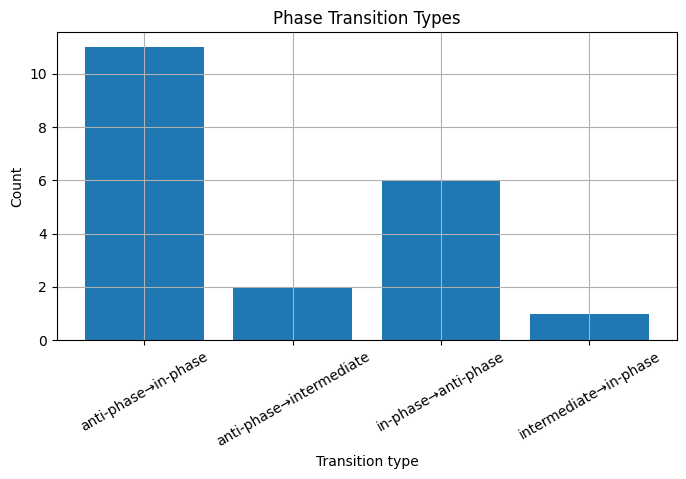

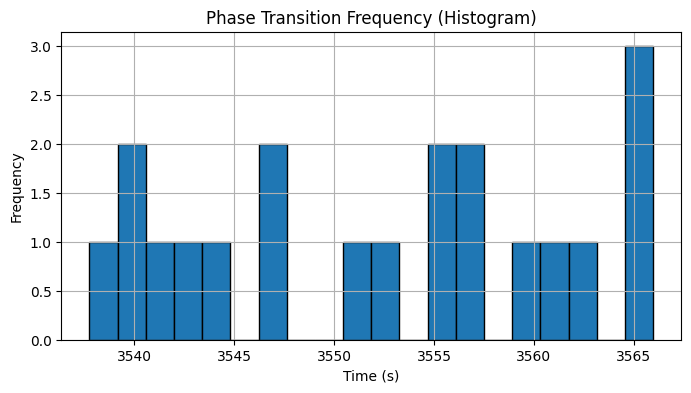

In [6]:
# plot_transition_bar(transitions)
plot_transition_types(transitions)
plot_transition_histogram(transitions)

In [7]:
# 1) check raw sliced data before resampling
df_raw = load_and_clean_data("data/nc0304_pilot_data_truncated.xlsx")
df = divide_data(df_raw, 3507+30, 3507+60)

print(df[["time", "angle_p1", "angle_p2", "i1", "i2"]].isna().sum())

# 2) check after unwrap + resample
df_u = unwrap_angles(df.copy())
df_rs = resample_signals(df_u, dt_target=1/114)

print(df_rs[["p1_unwrapped", "p2_unwrapped", "i1", "i2"]].isna().sum())

# 3) check which windows are bad
bad = []
for i, w in enumerate(phase_windows):
    if np.isnan(w["mean"]) or np.isnan(w["std"]):
        bad.append(i)

print("bad windows:", bad[:20], "count=", len(bad))

# 4) inspect one bad window
i = bad[0]
w = phase_windows[i]
print("window", i, "start", w["start"], "end", w["end"])
print("phi_wrapped NaNs:", np.isnan(w["phi_wrapped"]).sum())
print("phi_wrapped len:", len(w["phi_wrapped"]))

time        0
angle_p1    0
angle_p2    0
i1          0
i2          0
dtype: int64
p1_unwrapped    0
p2_unwrapped    0
i1              0
i2              0
dtype: int64
bad windows: [140, 167, 207, 214, 264] count= 5
window 140 start 3551.008818999987 end 3551.108818999987
phi_wrapped NaNs: 11
phi_wrapped len: 11


Verification:

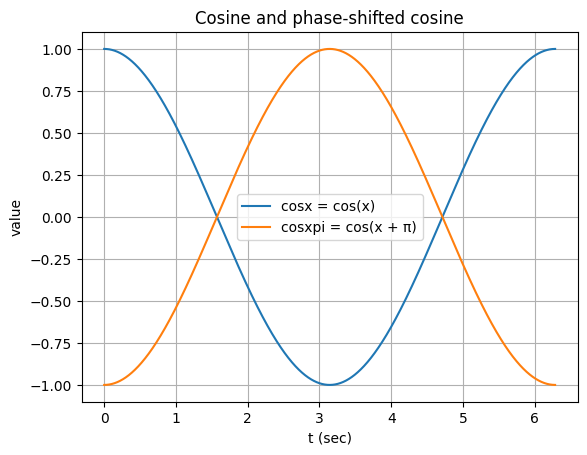

In [8]:
# x domain (radians)
x = np.linspace(0, 2*np.pi, 3894676)

# signals
cosx = np.cos(x)              # y = cos(x)
cosxpi = np.cos(x + np.pi)      # z = cos(x + pi) = -cos(x)
sh = np.cos(x +1/2*np.pi) 
sc = np.cos(x/2) 
c = 0.5
c_sig = np.full_like(x, c)

# plot
plt.figure()
plt.plot(x, cosx, label="cosx = cos(x)")
plt.plot(x, cosxpi, label="cosxpi = cos(x + π)")
# plt.plot(x, sh, label="sh = cos(x + 1/2*π)")
# plt.plot(x, sc, label="sc = cos(x/2)")
# plt.plot(x, c_sig, label="c = 0.5")   # constant line
plt.xlabel("t (sec)")
plt.ylabel("value")
plt.title("Cosine and phase-shifted cosine")
plt.grid(True)
plt.legend()
plt.show()

In [9]:

window_size=0.5
freq_band = (0, 100)
phase_jump_thresh = np.deg2rad(45)
smooth_k=3
min_dwell=2

windows = windowed_phase_analysis(
    cosx,
    cosxpi,
    t_rs,
    window_size=window_size,
    freq_band=freq_band,
)

transitions, transition_summary = detect_phase_transitions(
    windows,
    phase_jump_thresh=phase_jump_thresh,
    smooth_k=smooth_k,
    min_dwell=min_dwell,
)

Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.         2.2335146  2.49429374]...[400.91509099 447.72485467 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00803213 2.2473602  2.51521267]...[399.1774039  446.75351364 500.        ], nfreq=50
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.94719759 447.74278196 500.        ],

In [10]:

df_processed, phase_windows, transitions, transition_summary = run_full_pipeline(
    "data/simulated_cos_data_shifted.xlsx",
    0,
    2900,
    dt=1/114,
    window_size=0.5,
    freq_band=(0, 100),
    phase_jump_thresh=np.deg2rad(45),
    smooth_k=3,
    min_dwell=2,
)

Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.964

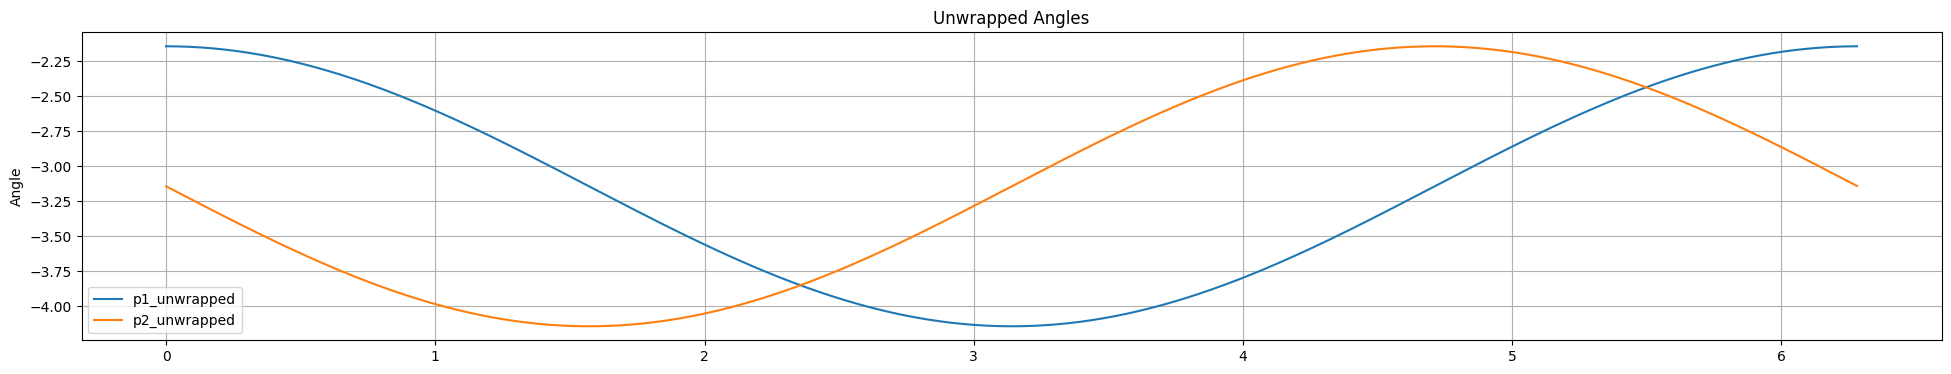

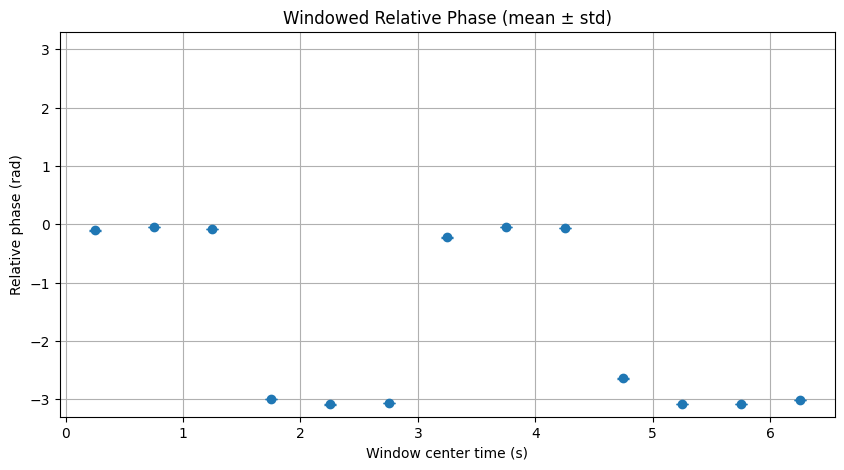

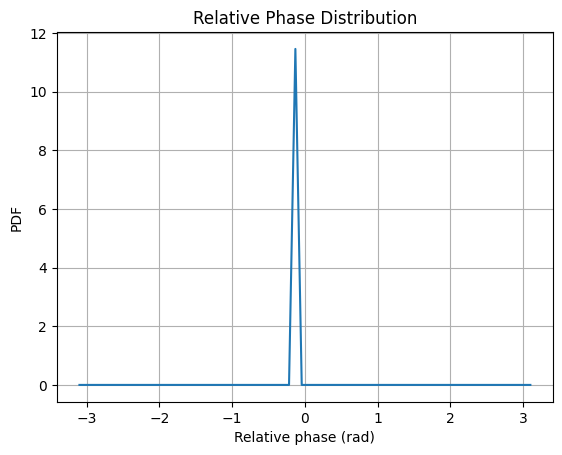

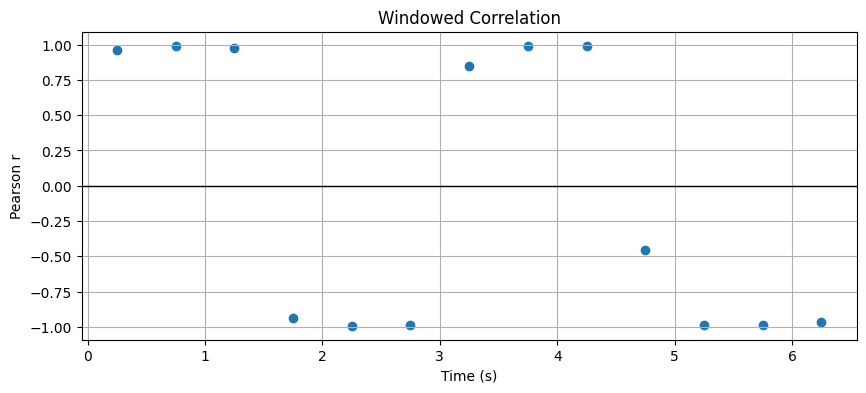

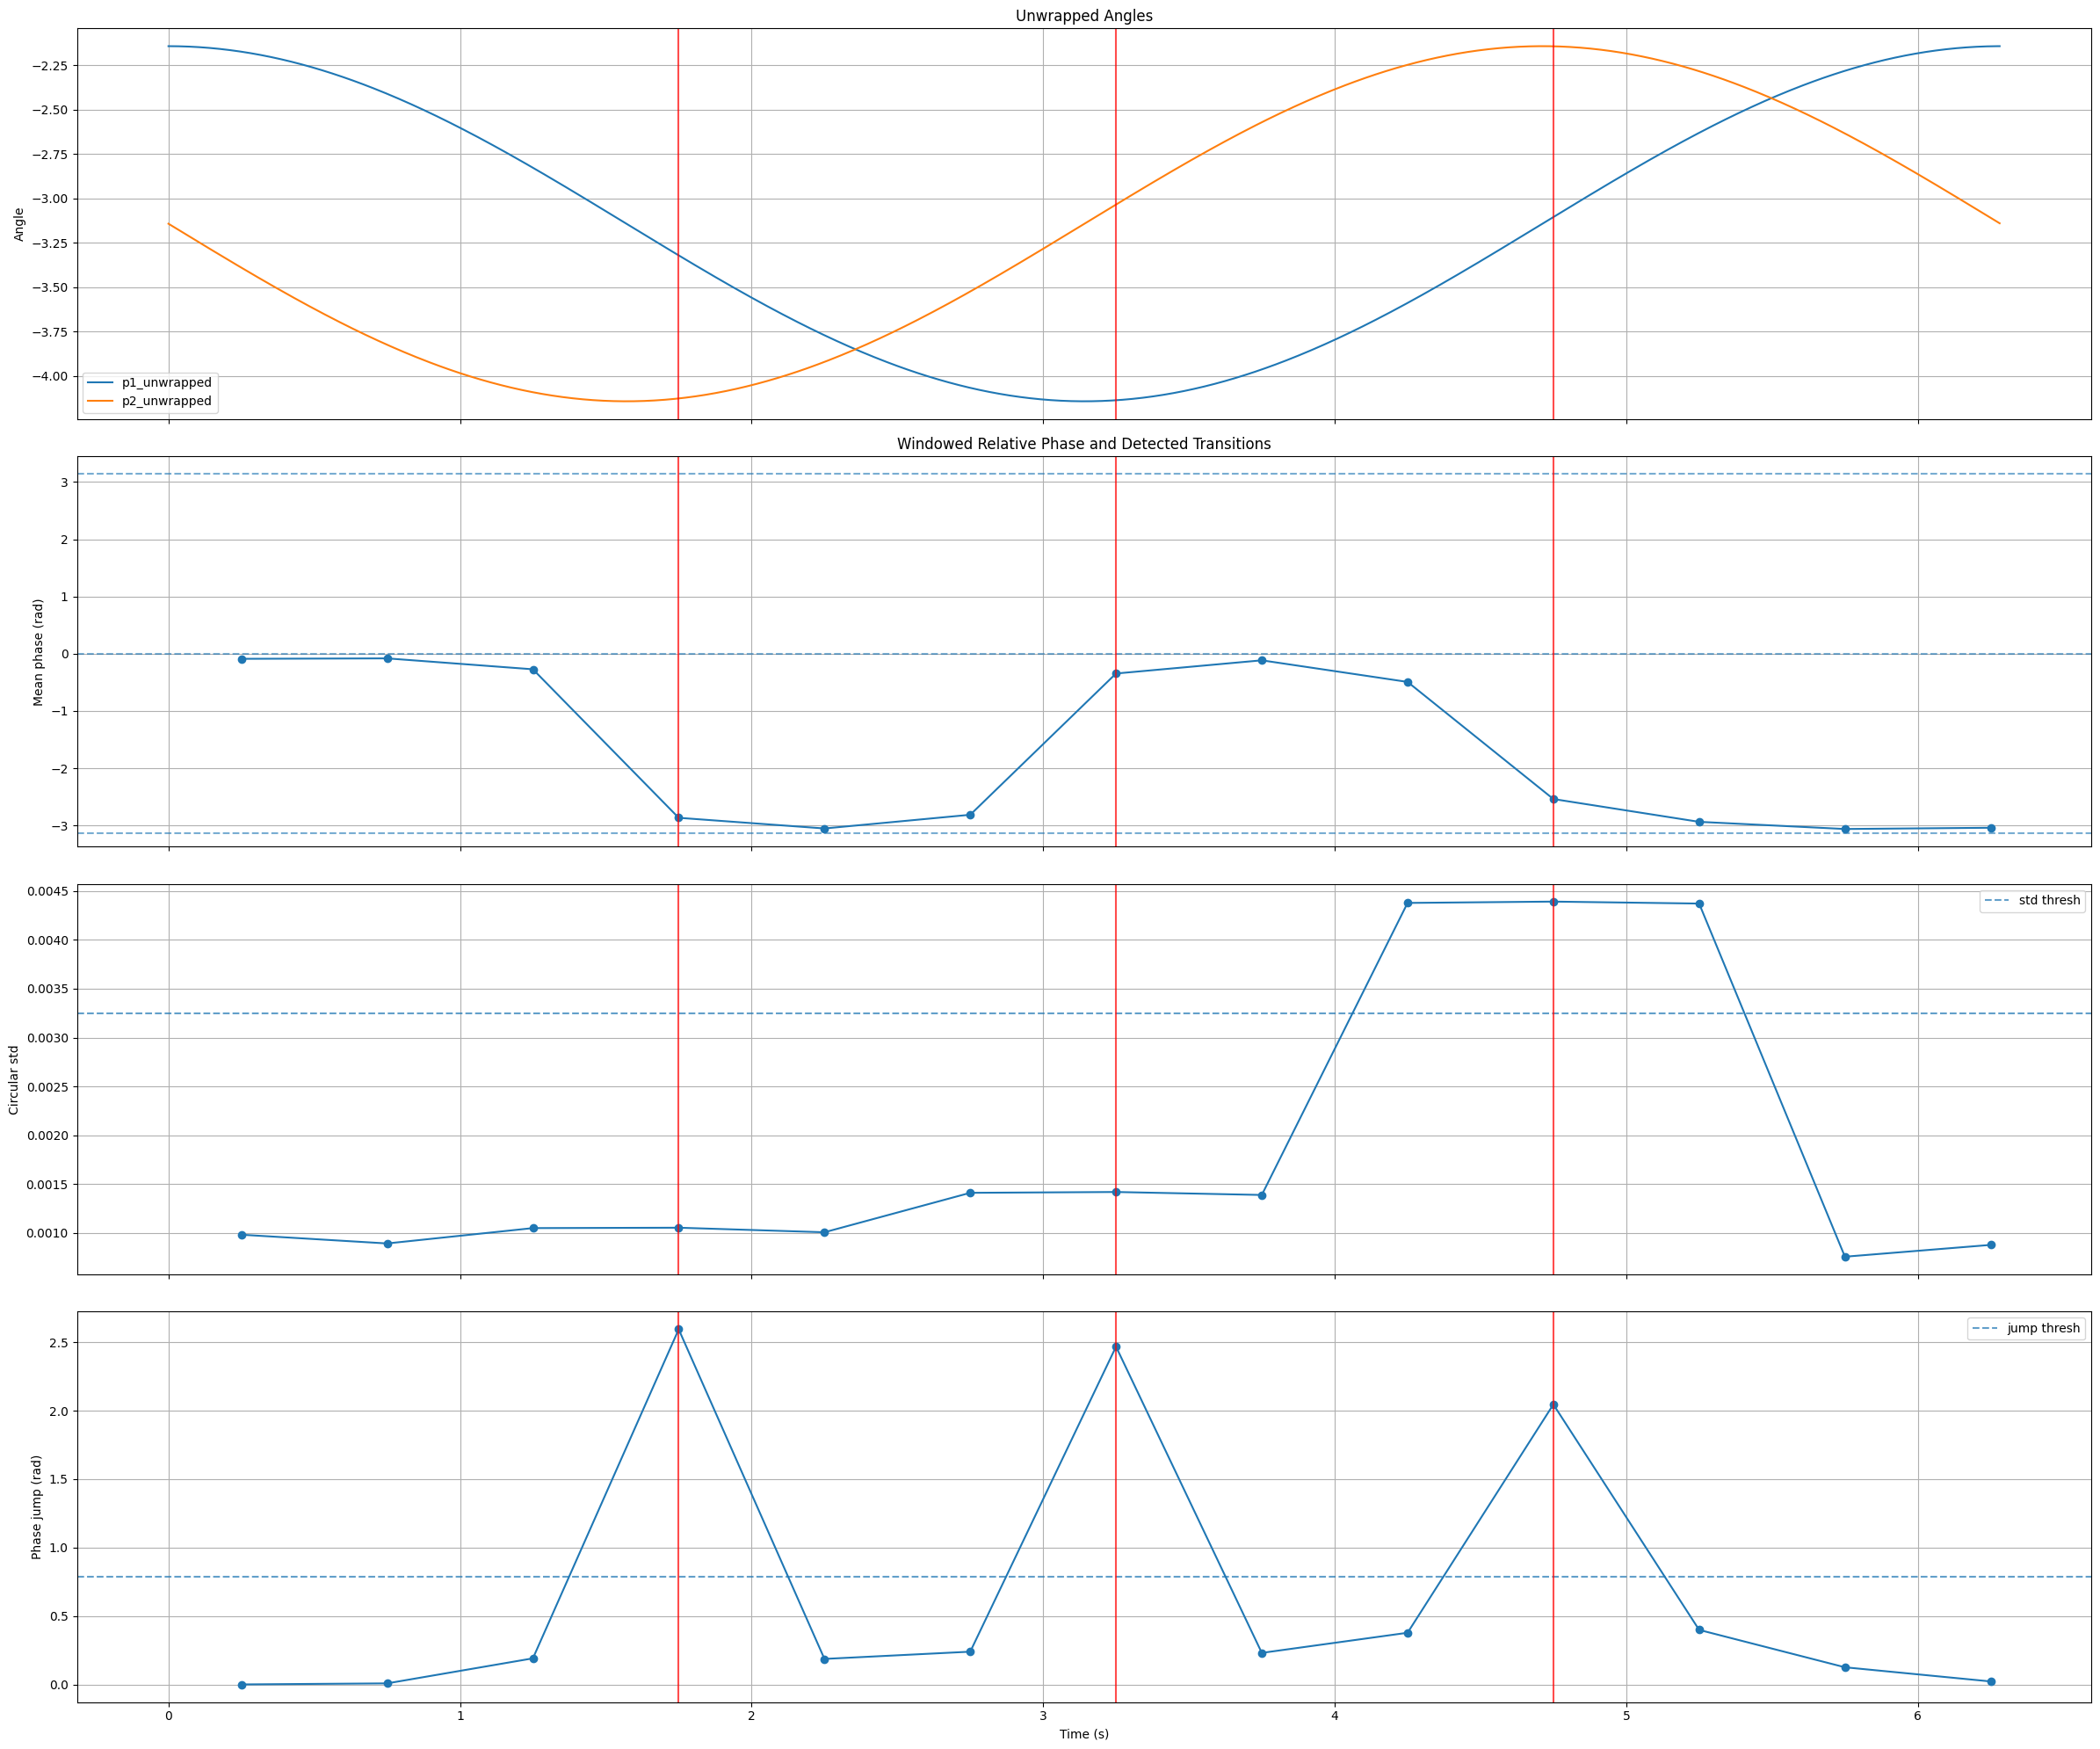

Transition at t=1.750s | in-phase -> anti-phase | jump=148.6 deg | std=0.001
Transition at t=3.250s | anti-phase -> in-phase | jump=141.4 deg | std=0.001
Transition at t=4.750s | in-phase -> anti-phase | jump=117.2 deg | std=0.004


In [11]:
plot_angles(
    df_processed["time"],
    df_processed["p1_unwrapped"],
    df_processed["p2_unwrapped"],
)

# plot_angular_velocity(
#     df_processed["time"],
#     df_processed["omega1"],
#     df_processed["omega2"],
# )

plot_windowed_phase(phase_windows)
plot_windowed_correlation(phase_windows)
plot_phase_transitions(transition_summary, transitions, df_processed)

for tr in transitions:
    print(
        f"Transition at t={tr['time']:.3f}s | "
        f"{tr['from_state']} -> {tr['to_state']} | "
        f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
        f"std={tr['std']:.3f}"
    )

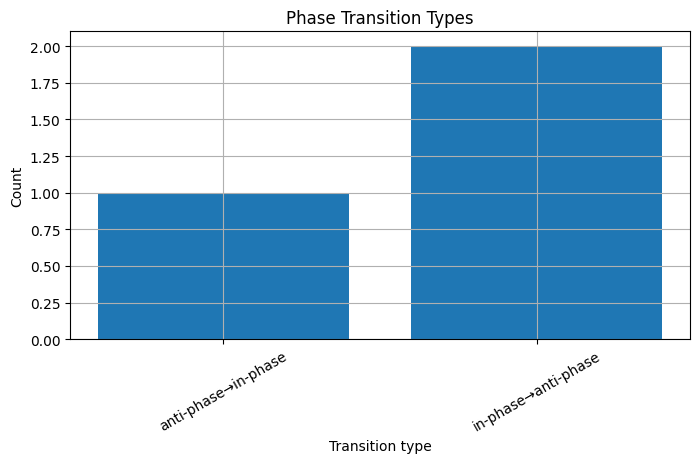

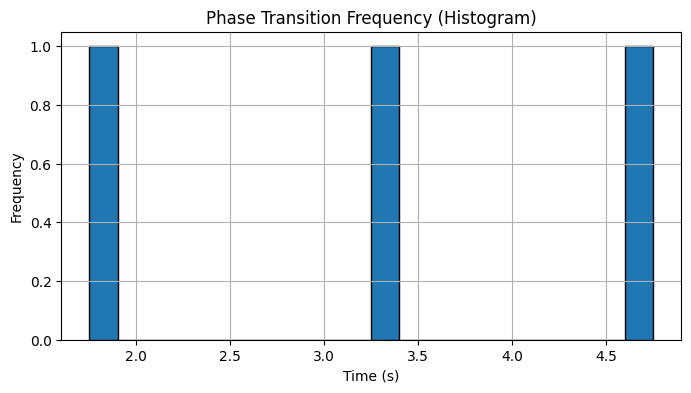

In [12]:
# plot_transition_bar(transitions)
plot_transition_types(transitions)
plot_transition_histogram(transitions)